 Install / Import Libraries

In [1]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
import random

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

 Upload ZIP File

In [2]:
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print("Uploaded file:", zip_name)

Saving Brain Tumor MRI images.zip to Brain Tumor MRI images.zip
Uploaded file: Brain Tumor MRI images.zip


Extract ZIP File

In [3]:
extract_path = "/content/mri_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Brain Tumor MRI images', '__MACOSX']


Find Tumor and Normal Folders

In [5]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

tumor_folder = None
normal_folder = None

for root, dirs, files_list in os.walk(extract_path):

    # Skip Mac system folders
    if "__MACOSX" in root:
        continue

    folder_name = os.path.basename(root).lower()

    # Detect tumor folder
    if "tumor" in folder_name and "no" not in folder_name:
        tumor_folder = root

    # Detect normal/no tumor folder
    elif (
        "normal" in folder_name
        or "no tumor" in folder_name
        or "notumor" in folder_name
        or "healthy" in folder_name
        or "no_tumor" in folder_name
    ):
        normal_folder = root

print("Tumor folder:", tumor_folder)
print("Normal folder:", normal_folder)

if tumor_folder is None or normal_folder is None:
    print("\nCould not automatically detect folders.")
    print("\nFolders inside dataset:\n")

    for root, dirs, files_list in os.walk(extract_path):
        if "__MACOSX" not in root:
            print(root)

Tumor folder: /content/mri_dataset/Brain Tumor MRI images/Tumor
Normal folder: /content/mri_dataset/Brain Tumor MRI images/Healthy


Load Images and Labels

In [6]:
IMG_SIZE = 224

images = []
labels = []
image_paths = []

def load_images_from_folder(folder, label):
    for filename in os.listdir(folder):
        if filename.lower().endswith(image_extensions):
            path = os.path.join(folder, filename)
            img = cv2.imread(path)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)
                image_paths.append(path)

load_images_from_folder(tumor_folder, 1)
load_images_from_folder(normal_folder, 0)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Tumor images:", np.sum(labels == 1))
print("Normal images:", np.sum(labels == 0))
print("Image shape:", images[0].shape)

Total images loaded: 5000
Tumor images: 3000
Normal images: 2000
Image shape: (224, 224, 3)



Sample MRI Images

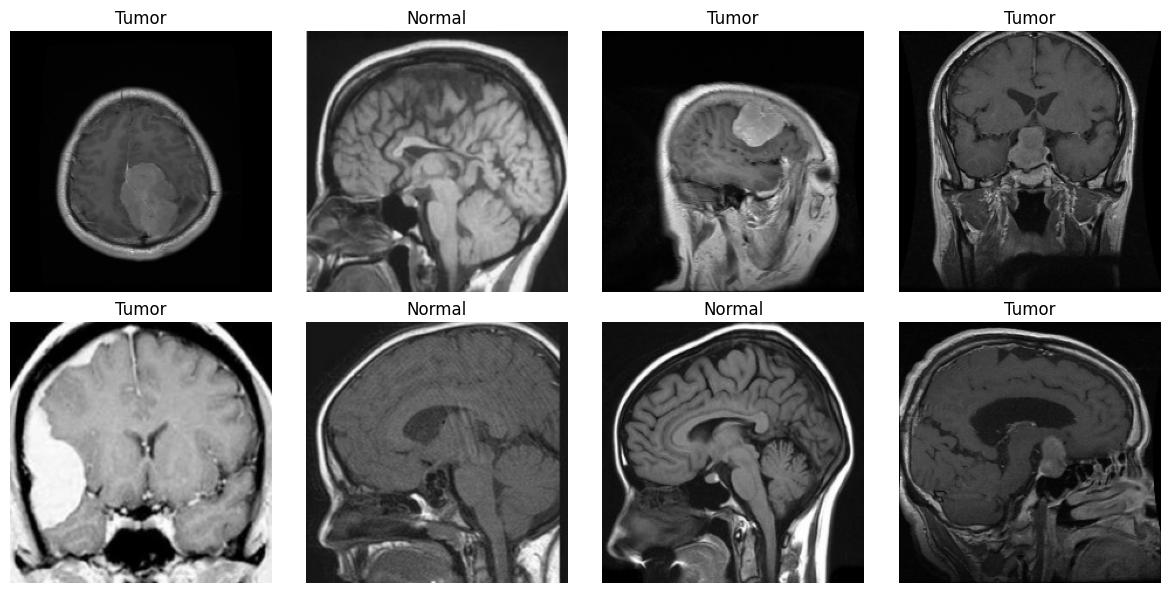

In [7]:
plt.figure(figsize=(12, 6))

for i in range(8):
    idx = random.randint(0, len(images)-1)
    img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i+1)
    plt.imshow(img_rgb)
    plt.title("Tumor" if labels[idx] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

Preprocessing Function

In [8]:
def preprocess_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise removal
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Contrast enhancement
    equalized = cv2.equalizeHist(blurred)

    return gray, blurred, equalized

Original vs Preprocessed Images

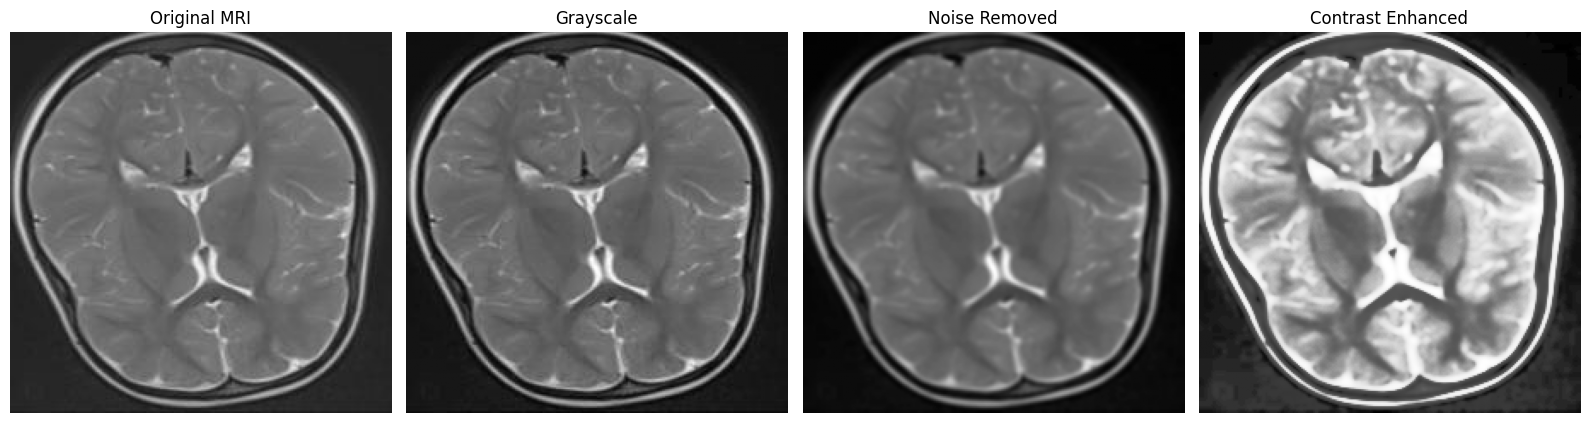

In [9]:
idx = random.randint(0, len(images)-1)
sample = images[idx]

gray, blurred, equalized = preprocess_image(sample)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(equalized, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

Tumor Segmentation using Thresholding, Edges and Contours

In [10]:
def segment_tumor(img):
    gray, blurred, equalized = preprocess_image(img)

    # Thresholding
    _, thresh = cv2.threshold(equalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Edge detection
    edges = cv2.Canny(equalized, 50, 150)

    # Morphological operation to clean noise
    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = img.copy()

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)

        if area > 100:
            x, y, w, h = cv2.boundingRect(largest_contour)
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.drawContours(output, [largest_contour], -1, (0, 0, 255), 2)

    return gray, equalized, thresh, edges, cleaned, output

Segmentation Result for One Image

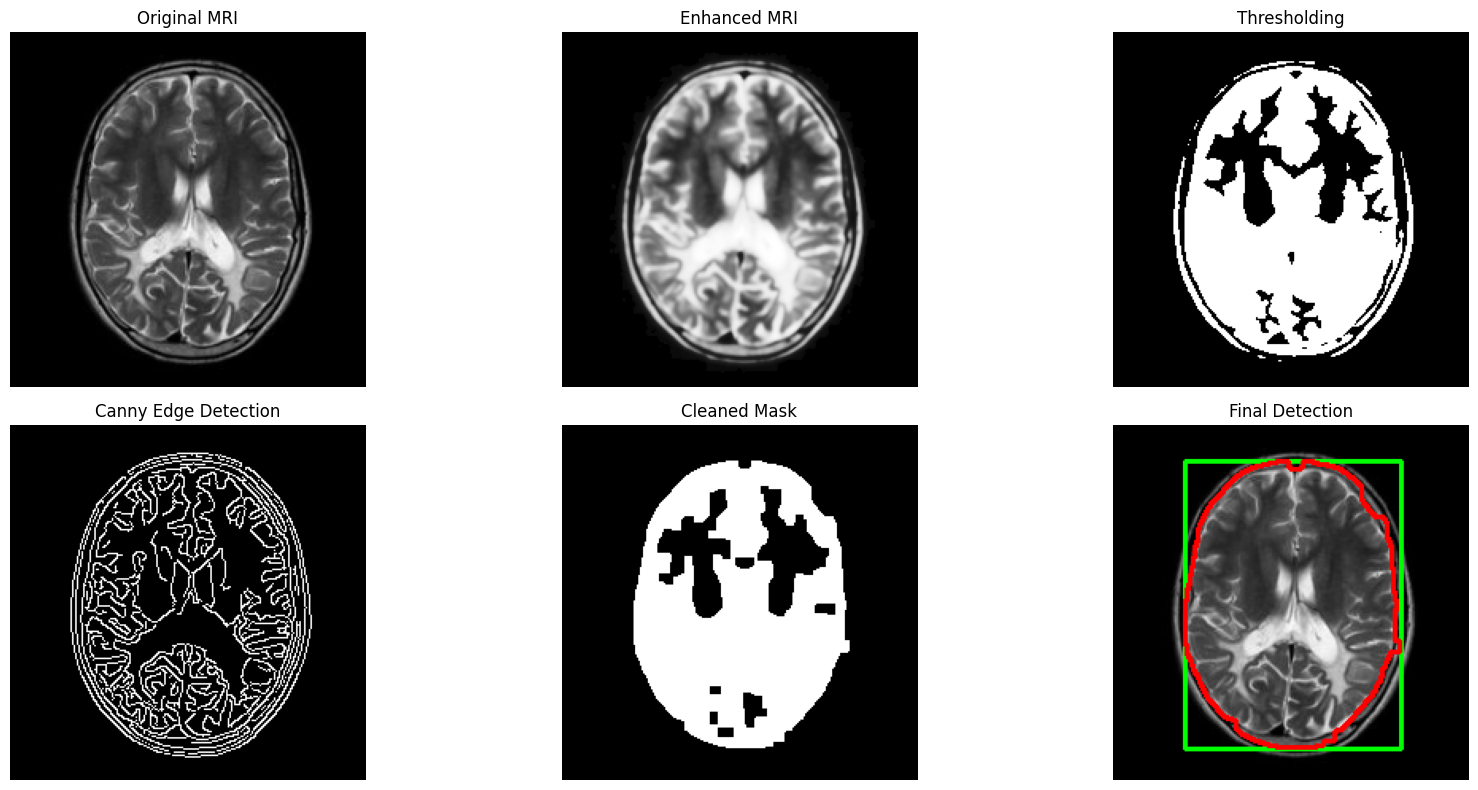

In [11]:
idx = random.randint(0, len(images)-1)
sample = images[idx]

gray, equalized, thresh, edges, cleaned, output = segment_tumor(sample)

plt.figure(figsize=(18, 8))

titles = [
    "Original MRI",
    "Enhanced MRI",
    "Thresholding",
    "Canny Edge Detection",
    "Cleaned Mask",
    "Final Detection"
]

display_images = [
    cv2.cvtColor(sample, cv2.COLOR_BGR2RGB),
    equalized,
    thresh,
    edges,
    cleaned,
    cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
]

for i in range(6):
    plt.subplot(2, 3, i+1)
    if i == 0 or i == 5:
        plt.imshow(display_images[i])
    else:
        plt.imshow(display_images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Feature Extraction for Machine Learning

In [12]:
def extract_features(img):
    gray, blurred, equalized = preprocess_image(img)

    # Intensity features
    mean_intensity = np.mean(equalized)
    std_intensity = np.std(equalized)
    min_intensity = np.min(equalized)
    max_intensity = np.max(equalized)

    # Edge features
    edges = cv2.Canny(equalized, 50, 150)
    edge_pixels = np.sum(edges > 0)

    # Contour features
    _, thresh = cv2.threshold(equalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_count = len(contours)
    largest_area = 0

    if len(contours) > 0:
        largest_area = max(cv2.contourArea(c) for c in contours)

    # Texture-like feature using Laplacian variance
    texture_value = cv2.Laplacian(equalized, cv2.CV_64F).var()

    features = [
        mean_intensity,
        std_intensity,
        min_intensity,
        max_intensity,
        edge_pixels,
        contour_count,
        largest_area,
        texture_value
    ]

    return features

Create Feature Dataset

In [13]:
feature_list = []

for img in images:
    features = extract_features(img)
    feature_list.append(features)

X = np.array(feature_list)
y = labels

feature_names = [
    "Mean Intensity",
    "Standard Deviation",
    "Minimum Intensity",
    "Maximum Intensity",
    "Edge Pixels",
    "Contour Count",
    "Largest Contour Area",
    "Texture Value"
]

df = pd.DataFrame(X, columns=feature_names)
df["Label"] = y

df.head()

,Mean Intensity,Standard Deviation,Minimum Intensity,Maximum Intensity,Edge Pixels,Contour Count,Largest Contour Area,Texture Value,Label
0,131.733239,68.798853,0.0,255.0,5784.0,1.0,26107.0,360.424278,1
1,96.790478,83.504124,0.0,255.0,5460.0,2.0,27915.0,239.124541,1
2,102.438895,82.840017,0.0,255.0,5023.0,2.0,22860.0,276.454821,1
3,128.150490,73.929151,0.0,255.0,7754.0,15.0,25709.0,1019.285358,1
4,88.188756,84.620093,0.0,255.0,5651.0,1.0,20697.0,715.541574,1


Split Dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


Scale Features

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Random Forest Classifier

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


Evaluate Model

In [17]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Tumor"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.946

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93       400
       Tumor       0.95      0.96      0.96       600

    accuracy                           0.95      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
[[369  31]
 [ 23 577]]


Plot Confusion Matrix

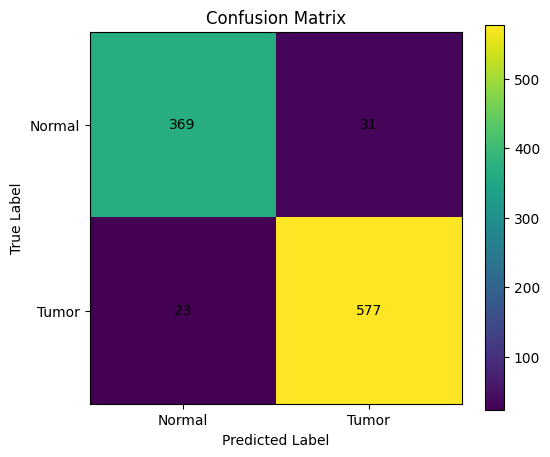

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Normal", "Tumor"])
plt.yticks([0, 1], ["Normal", "Tumor"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Feature Importance

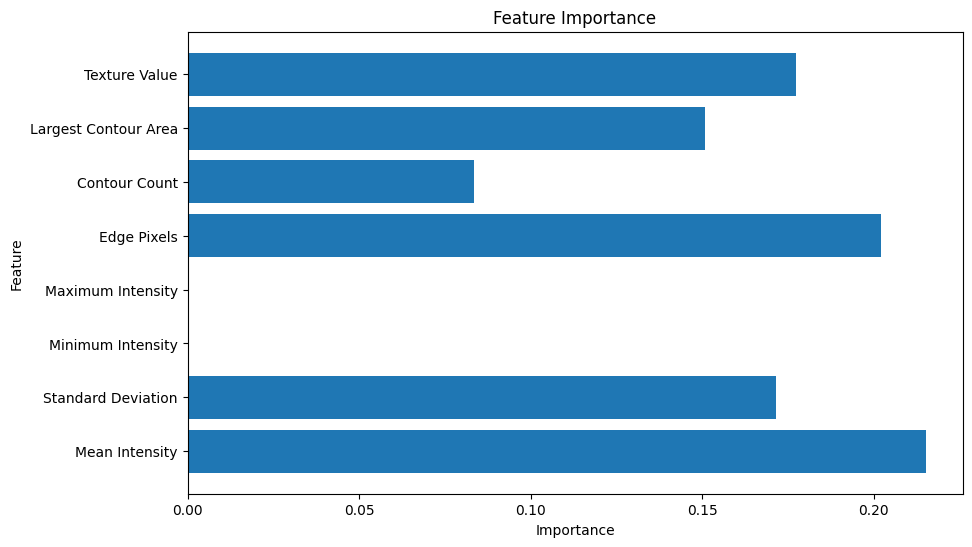

In [19]:
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Test Prediction on Random Images

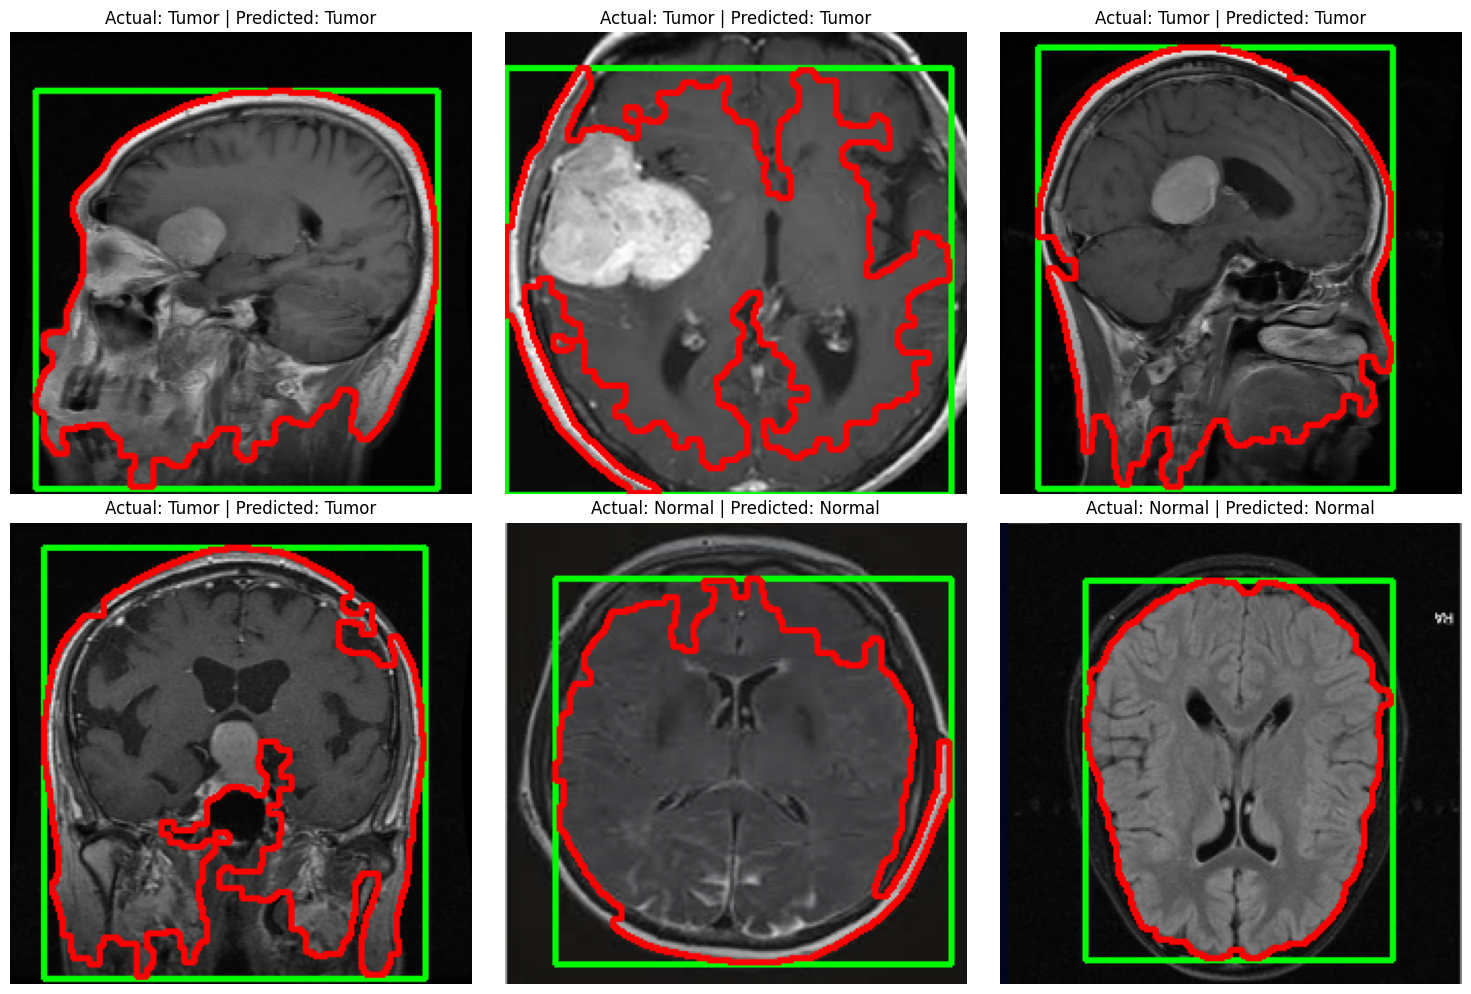

In [20]:
plt.figure(figsize=(15, 10))

for i in range(6):
    idx = random.randint(0, len(images)-1)
    img = images[idx]

    features = np.array(extract_features(img)).reshape(1, -1)
    features_scaled = scaler.transform(features)

    prediction = model.predict(features_scaled)[0]
    actual = labels[idx]

    result_img = segment_tumor(img)[-1]
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(result_img)
    plt.title(f"Actual: {'Tumor' if actual==1 else 'Normal'} | Predicted: {'Tumor' if prediction==1 else 'Normal'}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Save Output Images for Report

In [21]:
output_folder = "/content/output_results"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

os.makedirs(output_folder, exist_ok=True)

count = 0

for i in range(min(10, len(images))):
    img = images[i]
    label = labels[i]

    gray, equalized, thresh, edges, cleaned, output = segment_tumor(img)

    cv2.imwrite(f"{output_folder}/image_{i+1}_original.jpg", img)
    cv2.imwrite(f"{output_folder}/image_{i+1}_enhanced.jpg", equalized)
    cv2.imwrite(f"{output_folder}/image_{i+1}_threshold.jpg", thresh)
    cv2.imwrite(f"{output_folder}/image_{i+1}_edges.jpg", edges)
    cv2.imwrite(f"{output_folder}/image_{i+1}_final_detection.jpg", output)

    count += 1

print(count, "sets of output images saved.")
print("Output folder:", output_folder)

10 sets of output images saved.
Output folder: /content/output_results


Create Final ZIP of Output Images

In [22]:
shutil.make_archive("/content/mri_project_outputs", "zip", output_folder)

print("Output ZIP created successfully!")

Output ZIP created successfully!


Download Output ZIP

In [23]:
files.download("/content/mri_project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save Feature Table as CSV

In [24]:
df.to_csv("/content/mri_features.csv", index=False)

files.download("/content/mri_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJECT SUMMARY

1. Dataset Loading

* MRI brain scan dataset was uploaded to Google Colab using a ZIP file.
* The dataset contains two folders:
* Tumor MRI Images
* Normal MRI Images
* All images were loaded successfully for processing and analysis.

2. Image Preprocessing
    The following preprocessing techniques were applied to improve image quality:

* Images were resized to 224 × 224 pixels.
* Images were converted to grayscale format.
* Gaussian Blur was used for noise removal and smoothing.
* Histogram Equalization was applied for contrast enhancement.

3. Image Processing Techniques
    Several image-processing methods were used to analyze MRI images:

* Thresholding was used to separate important regions from the background.
* Canny Edge Detection was used to identify edges and boundaries.
* Morphological operations were applied to reduce unwanted noise.
* Contour Detection was used to identify possible tumor regions.
* Bounding boxes and contours were drawn around detected regions.

4. Feature Extraction
    Important features were extracted from MRI images, including:

* Intensity information
* Edge information
* Contour information
* Texture features

These features were used for machine learning classification.

5. Machine Learning Model

* Random Forest Classifier was used as the machine learning model.
* The dataset was divided into training and testing datasets.
* The model was trained to classify MRI images into:
* Tumor
* Normal

6. Model Evaluation
    The trained model was evaluated using:

* Accuracy Score
* Classification Report
* Confusion Matrix

7. Outputs Generated
    The system generated the following outputs:

* Original MRI images
* Enhanced images
* Threshold images
* Edge detection images
* Segmented tumor detection results
* Final classification predictions

8. Final Result
    The project successfully processed MRI images, enhanced image quality, detected tumor regions, extracted important features, and classified MRI images into tumor and normal categories using image processing and machine learning techniques.